<a href="https://colab.research.google.com/github/sathvikaaa7/Crop_Yield_Prediction/blob/main/Crop_Yield_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [322]:
!pip install xgboost

In [323]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import StackingRegressor

from sklearn.linear_model import LinearRegression

In [324]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("akshatgupta7/crop-yield-in-indian-states-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'crop-yield-in-indian-states-dataset' dataset.
Path to dataset files: /kaggle/input/crop-yield-in-indian-states-dataset


In [325]:
import os

os.listdir('/kaggle/input/crop-yield-in-indian-states-dataset')

['crop_yield.csv']

In [326]:
import pandas as pd

df = pd.read_csv('/kaggle/input/crop-yield-in-indian-states-dataset/crop_yield.csv')

df.head()

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909


In [327]:
df = df.drop(['Production','Area'], axis=1)

In [328]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             19689 non-null  object 
 1   Crop_Year        19689 non-null  int64  
 2   Season           19689 non-null  object 
 3   State            19689 non-null  object 
 4   Annual_Rainfall  19689 non-null  float64
 5   Fertilizer       19689 non-null  float64
 6   Pesticide        19689 non-null  float64
 7   Yield            19689 non-null  float64
dtypes: float64(4), int64(1), object(3)
memory usage: 1.2+ MB


In [329]:
df.describe()

,Crop_Year,Annual_Rainfall,Fertilizer,Pesticide,Yield
count,19689.000000,19689.000000,1.968900e+04,1.968900e+04,19689.000000
mean,2009.127584,1437.755177,2.410331e+07,4.884835e+04,79.954009
std,6.498099,816.909589,9.494600e+07,2.132874e+05,878.306193
min,1997.000000,301.300000,5.417000e+01,9.000000e-02,0.000000
25%,2004.000000,940.700000,1.880146e+05,3.567000e+02,0.600000
50%,2010.000000,1247.600000,1.234957e+06,2.421900e+03,1.030000
75%,2015.000000,1643.700000,1.000385e+07,2.004170e+04,2.388889
max,2020.000000,6552.700000,4.835407e+09,1.575051e+07,21105.000000


In [330]:
df.isnull().sum()

,0
Crop,0
Crop_Year,0
Season,0
State,0
Annual_Rainfall,0
Fertilizer,0
Pesticide,0
Yield,0


In [331]:
from sklearn.preprocessing import LabelEncoder

df['Crop'] = df['Crop'].str.strip()
df['Season'] = df['Season'].str.strip()
df['State'] = df['State'].str.strip()

crop_encoder = LabelEncoder()
season_encoder = LabelEncoder()
state_encoder = LabelEncoder()

crop_encoder.fit(df['Crop'])
season_encoder.fit(df['Season'])
state_encoder.fit(df['State'])

df['Crop'] = crop_encoder.transform(df['Crop'])
df['Season'] = season_encoder.transform(df['Season'])
df['State'] = state_encoder.transform(df['State'])

In [332]:
df.head()

,Crop,Crop_Year,Season,State,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,0,1997,4,2,2051.4,7024878.38,22882.34,0.796087
1,1,1997,1,2,2051.4,631643.29,2057.47,0.710435
2,8,1997,1,2,2051.4,75755.32,246.76,0.238333
3,9,1997,4,2,2051.4,1870661.52,6093.36,5238.051739
4,11,1997,1,2,2051.4,165500.63,539.09,0.420909


In [333]:
df = df[df['Yield'] < df['Yield'].quantile(0.99)]

In [334]:
X = df.drop('Yield', axis=1)
y = df['Yield']

In [335]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [336]:
dt = DecisionTreeRegressor(max_depth=10)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [337]:
print("Decision Tree R2:", r2_score(y_test, dt_pred))

Decision Tree R2: 0.9023230376433424


In [338]:
rf = RandomForestRegressor(n_estimators=50)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest R2:", r2_score(y_test, rf_pred))

Random Forest R2: 0.9481882751262918


In [339]:
gb = GradientBoostingRegressor()

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

print("Gradient Boosting R2:", r2_score(y_test, gb_pred))

Gradient Boosting R2: 0.7953334618017431


In [340]:
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [341]:
from sklearn.metrics import r2_score

print("XGBoost R2:", r2_score(y_test, xgb_pred))

XGBoost R2: 0.9352152164245338


In [342]:
base_models = [
    ('rf', RandomForestRegressor(n_estimators=50)),
    ('gb', GradientBoostingRegressor()),
    ('dt', DecisionTreeRegressor(max_depth=10)),
    ('xgb', XGBRegressor())
]

stack = StackingRegressor(
    estimators=base_models,
    final_estimator=LinearRegression(),
    cv=3
)

In [343]:
stack.fit(X_train, y_train)

StackingRegressor(cv=3,
                  estimators=[('rf', RandomForestRegressor(n_estimators=50)),
                              ('gb', GradientBoostingRegressor()),
                              ('dt', DecisionTreeRegressor(max_depth=10)),
                              ('xgb',
                               XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=Fa...
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=None, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=None, n_jobs=None,
                                            num_parallel_tree=None, ...))],
                  final_estimator=LinearRegression())

In [344]:
stack_pred = stack.predict(X_test)

print("Stacking Model R2:", r2_score(y_test, stack_pred))

Stacking Model R2: 0.9498876986111285


In [345]:
results = {
    "Decision Tree": r2_score(y_test, dt_pred),
    "Random Forest": r2_score(y_test, rf_pred),
    "Gradient Boosting": r2_score(y_test, gb_pred),
    "XGBoost" : r2_score(y_test, xgb_pred),
    "Stacking Ensemble": r2_score(y_test, stack_pred)
}

print(results)

{'Decision Tree': 0.9023230376433424, 'Random Forest': 0.9481882751262918, 'Gradient Boosting': 0.7953334618017431, 'XGBoost': 0.9352152164245338, 'Stacking Ensemble': 0.9498876986111285}


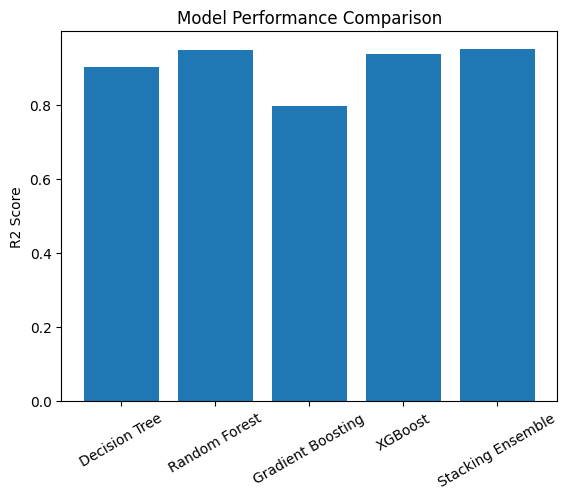

In [346]:
plt.bar(results.keys(), results.values())

plt.title("Model Performance Comparison")

plt.ylabel("R2 Score")

plt.xticks(rotation=30)

plt.show()

In [347]:
print("Available Crops:", list(crop_encoder.classes_))
print("\nAvailable Seasons:", list(season_encoder.classes_))
print("\nAvailable States:", list(state_encoder.classes_))

Available Crops: ['Arecanut', 'Arhar/Tur', 'Bajra', 'Banana', 'Barley', 'Black pepper', 'Cardamom', 'Cashewnut', 'Castor seed', 'Coconut', 'Coriander', 'Cotton(lint)', 'Cowpea(Lobia)', 'Dry chillies', 'Garlic', 'Ginger', 'Gram', 'Groundnut', 'Guar seed', 'Horse-gram', 'Jowar', 'Jute', 'Khesari', 'Linseed', 'Maize', 'Masoor', 'Mesta', 'Moong(Green Gram)', 'Moth', 'Niger seed', 'Oilseeds total', 'Onion', 'Other  Rabi pulses', 'Other Cereals', 'Other Kharif pulses', 'Other Summer Pulses', 'Peas & beans (Pulses)', 'Potato', 'Ragi', 'Rapeseed &Mustard', 'Rice', 'Safflower', 'Sannhamp', 'Sesamum', 'Small millets', 'Soyabean', 'Sugarcane', 'Sunflower', 'Sweet potato', 'Tapioca', 'Tobacco', 'Turmeric', 'Urad', 'Wheat', 'other oilseeds']

Available Seasons: ['Autumn', 'Kharif', 'Rabi', 'Summer', 'Whole Year', 'Winter']

Available States: ['Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chhattisgarh', 'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir', 'Jhark

In [348]:
print("\nEnter the following details:\n")

crop = input("Enter Crop: ").strip()

season = input("Enter Season: ").strip()

state = input("Enter State: ").strip()

year = int(input("Enter Crop Year: "))
rainfall = float(input("Enter Annual Rainfall (mm): "))
fertilizer = float(input("Enter Fertilizer usage (kg per hectare): "))
pesticide = float(input("Enter Pesticide usage (kg per hectare): "))

try:
    crop_encoded = crop_encoder.transform([crop])[0]
    season_encoded = season_encoder.transform([season])[0]
    state_encoded = state_encoder.transform([state])[0]
except ValueError:
    print("\nInvalid input detected.")
    print("Please enter values exactly as shown in the lists above.")
    raise

input_data = pd.DataFrame({
    'Crop': [crop_encoded],
    'Crop_Year': [year],
    'Season': [season_encoded],
    'State': [state_encoded],
    'Annual_Rainfall': [rainfall],
    'Fertilizer': [fertilizer],
    'Pesticide': [pesticide]
})

input_data = input_data[X.columns]

prediction = stack.predict(input_data)

print("\n Predicted Crop Yield:", prediction[0], "tonnes per hectare")


Enter the following details:

Enter Crop: Banana
Enter Season: Rabi
Enter State: Kerala
Enter Crop Year: 2026
Enter Annual Rainfall (mm): 3000
Enter Fertilizer usage (kg per hectare): 3
Enter Pesticide usage (kg per hectare): 2

 Predicted Crop Yield: 2.09071259802489 tonnes per hectare
